<a href="https://colab.research.google.com/github/iestleija/5094-Matematicas/blob/Unidad4/Unidad4/Practices/5094_U4_D3_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos

- Curso: **Matemáticas y estadística para inteligencia artificial**

- Semestre: Enero-Junio

- Profesor: Dra. Helen Clara Peñate Rodríguez
- Actividad: **D3. Optimización: Máximos y Mínimos**
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

#D3. Optimización: Máximos y Mínimos
Enlace a colab: https://colab.research.google.com/drive/1BfnmmkA84Rk8WJODQ0MUlNLBcy6LN-ss?usp=sharing

# 1. Optimización del Tamaño de un Lote en Aprendizaje Automático
##1.1. Contexto

En entrenamiento de modelos de aprendizaje automático, el **tamaño del lote** $(B)$ es la cantidad de ejemplos utilizados en cada actualización de los pesos
del modelo. Elegir un $B$ adecuado es crucial:

- Si $B$ es pequeño: las actualizaciones del modelo son más ruidosas pero
pueden converger más rápido.
- Si B es grande: el modelo se entrena de manera más estable, pero puede necesitar más tiempo de cómputo y memoria.



El **tiempo total de entrenamiento** $(T(B))$ está determinado por dos factores:

- 1. Número de iteraciones necesarias: $N(B)$
- 2. Tiempo por iteración: $t(B)$ (en segundos)

Podemos modelar esto como:
$$T(B) = N(B)*t(B)$$
donde:

1. $N(B) \approx \frac {N_{total}} {B}$ (a mayor $B$ menos iteraciones).
2. $N_{total}$ es el número de ejemplos de entrenamiento.
3. $t(B) \approx t_0 + \frac {c} {N_{total}}B^3$
(cada iteración toma más tiempo con B más grande)
4. $t_0$ es el tiempo promedio por iteración en condiciones ideales.
5. $c$ es una constante positiva que captura el costo computacional de manejar
lotes grandes (en segundos por $B^2$
)


#Fórmula Extendida
A partir de la fórmula del tiempo total de entrenamiento,
$$T(B) = N(B)*t(B)$$

Y con las definiciones previas, se genera la siguiente fórmula extendida de la función
$$T(B) = \frac {N_{total}} {B}*t_0 + \frac {c} {N_{total}}B^3$$

##Cálculo del punto mínimo de la función $T(B)$

###Continuidad de la función
Como prerequisito para encontrar el punto mínimo se requiere que el valor de la función exista y coincida con el límite de la función en el mismo punto.

Considerando que $B$ en la función siguiente es la única variable y por su naturaleza es positiva, definida para todo $B \geq 0$.
Siendo $B$ la variable independiente, el dominio de la funcion esta definido para todo $B \geq 0$.

De la misma forma analizando los términos de la funcion y en el entendido que los demas valores son positivos, la función es continua para todo su dominio.

$$T(B) = \frac {N_{total}} {B}*t_0 + \frac {c} {N_{total}}B^3$$

De lo anterior se deduce que el valor de la función en el punto mínimo coincide con el límite de la funcion en el mismo punto

**Encuentre el tamaño de lote** $B$ que minimiza el tiempo total de entrenamiento $T(B)$.

Pasos del ejercicio:
1. Encuentre el punto estacionario de la función $T(B)$.
2. Verifique que dicho punto es un mínimo utilizando la condición suficiente de la segunda derivada


### Cálculo de la primera derivada
Vamos por la condición necesaria de que la primera derivada sea igual a cero.

$$T(B) = (N_{total} *t_0)*B^{-1} + \frac {c} {N_{total}}B^3$$

De aquí que **la primera derivada** es:
$$T'(B) = (-1)(N_{total}*t_0)*B^{-2} + 3*\frac {c} {N_{total}}*B^2$$


### Cálculo de los puntos estacionarios
Igualamos a cero la derivada,
$$-\frac {(N_{total}*t_0)}{B^2} + 3*\frac {c} {N_{total}}*B^2 = 0$$

Preparamos para despejar $B$,
$$\frac {3*c*B^2} {N_{total}} = \frac {N_{total} *t_0}{B^2}$$

Multiplicamos ambos lados por $B^2$,

$$ \frac {3c*B^2*B^2} {N_{total}} = \frac {N_{total} *t_0* {B^2}}{B^2}$$
$$ \frac {3c*B^4} {N_{total}} = {N_{total} *t_0}$$
Ahora, multiplicando ambos lados con $N_{total}$, queda,
$$ {3c*B^4}  = (N_{total})^2 *t_0$$

Despejando B, tenemos,
$$B^4 = \frac {(N_{total})^2 *t_0}{3c}$$
$$B = \sqrt[4] \frac {(N_{total})^2 *t_0}{3c}$$
Este será el valor del punto estacionario donde la primera derivada es cero. Este valor es dependiente de los parámetros del caso al que sea aplicada la función.





### Cálculo de la segunda derivada
El valor de la segunda derivada nos ayuda a clasificar el punto estacionario como un mímimo, un máximo o un punto de silla.

$$T''(B) = \frac {2*N_{total}*t_0}{B^3} + \frac {6c*B}{N_{total}}$$

Sabiendo que todos los parámetros que requiere la función son positivos,se entiende que esta segunda derivada será positiva en todos sus puntos. Por lo anterior nos encontramos ante un punto mínimo local.




Ejemplos de casos:

- El número de ejemplos de entrenamiento $N_{total}$ depende del dataset:
  - dataset pequeño: $10^4$
(10,000 ejemplos, como MNIST).
  - dataset mediano: $10^6$
(1 millón de ejemplos, como CIFAR-10).
  - dataset grande: $10^8$
(100 millones de ejemplos, como ImageNet)
- El tiempo base por iteración $t_0$ depende del hardware y del tipo de modelo.

>En general:
  - Modelos pequeños (MLP en CPU): $t_0 \approx 1ms − 10ms$ por iteración.
  - Modelos medianos (CNN pequeña en GPU): $t_0 \approx 0.1s − 1s$ por iteración.
  - Modelos grandes (Transformer en GPU): $t_0 \approx 1s−10s$ por iteración.
- El valor de $c$ modela el aumento de tiempo cuando $B$ es grande debido a:
  - Latencia de acceso a memoria.
  - Limitaciones de procesamiento paralelo en GPU/CPU.

>Típicamente, $c$ es pequeño pero positivo, en el rango $10^{−6} ≤ c ≤ 10^{−3}$



#Presentación Gráfica de dos Ejemplos

Muestre gráficamente dos ejemplos de funciones $T(B)$ utilizando valores factibles de parámetros. Señale en los gráficos el valor mínimo de la función según el resultado analítico obtenido anteriormente.

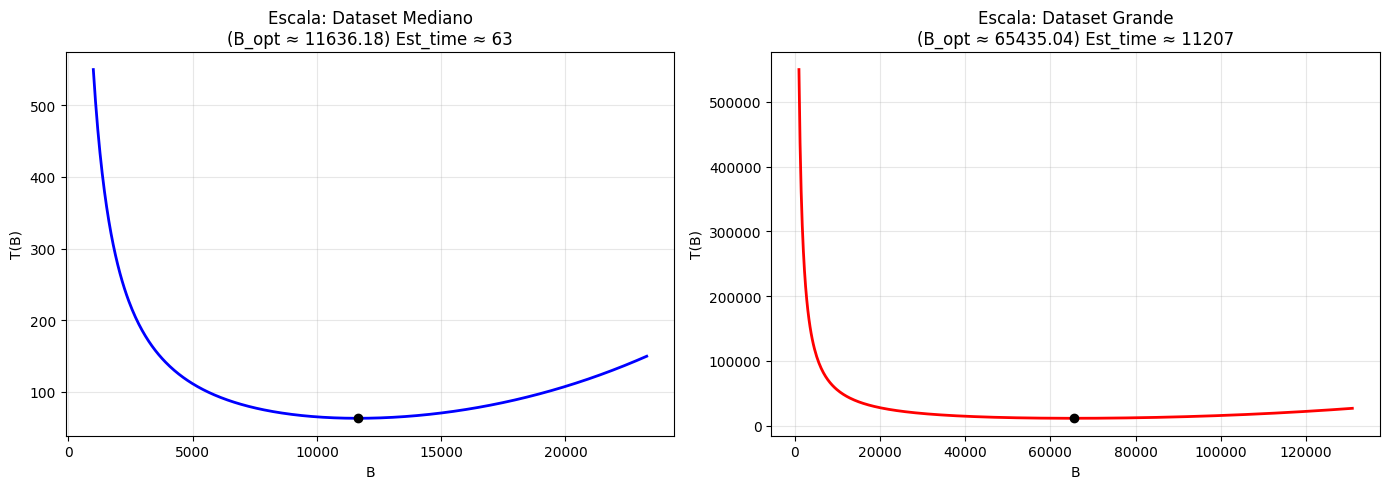

In [16]:
import numpy as np
import matplotlib.pyplot as plt

parameters = [
    # {
    #     "nombre": "Dataset Pequeño",
    #     "N_total": 10000,
    #     "t0": 5.5,
    #     "c": 0.0001,
    #     "color": "green"
    # },
    {
        "nombre": "Dataset Mediano",
        "N_total": 1000000,
        "t0": 0.55,
        "c": 0.00001,
        "color": "blue"
    },
    {
        "nombre": "Dataset Grande",
        "N_total": 100000000,
        "t0": 5.5,
        "c": 0.001,
        "color": "red"
    }
]

# Definir la función original
def training_time(B, p):
    return (p['N_total'] / B) * p['t0'] + (p['c'] / p['N_total']) * (B**3)

# Configurar el "grid" de 1 fila y 2 columnas
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for i, p in enumerate(parameters):
    # Cálculo del B óptimo para centrar la gráfica
    b_opt = ((p['N_total']**2 * p['t0']) / (3 * p['c']))**(1/4)

    # Crear rango de valores para B (de 1 hasta el doble del óptimo)
    b_vals = np.linspace(1000, b_opt * 2, 500)
    t_vals = training_time(b_vals, p)
    t_b = training_time(b_opt, p)

    # Graficar en el eje correspondiente
    axs[i].plot(b_vals, t_vals, color=p['color'], linewidth=2)
    axs[i].scatter(b_opt, training_time(b_opt, p), color='black', zorder=5) # Punto mínimo

    # Formato de cada gráfico
    axs[i].set_title(f"Escala: {p['nombre']}\n(B_opt ≈ {b_opt:.2f}) Est_time ≈ {t_b:.0f}")
    axs[i].set_xlabel("B")
    axs[i].set_ylabel("T(B)")
    axs[i].grid(True, alpha=0.3)

# Ajustar espacio entre gráficas
plt.tight_layout()
plt.show()


#Conclusión
Con el apoyo del material académico, el libro de Ivan, (Savov, 2014)   y el capítulo 4 del libro de Walter (Mora F., 2012) se completó la presente actividad en la que se aplicaron las técnicas de optimización a partir de derivadas a un caso particular en el ámbito del aprendizaje automático, para encontrar el lote óptimo para el tiempo de entrenamiento de un modelo.

#Referencias

Mora F., W. (2012). Cálculo en varias variables (1a ed.). Instituto Tecnológico de Costa Rica. https://doi.org/10.18845/mat.b12

Savov, I. (2014). No BULLSHIT guide to MATH & PHYSICS (v5.1).
